# Лабораторная работа №1, задание 3

**Условие.** Выбрать датасет (с Kaggle или из другого открытого источника) и с помощью описательной статистики и графиков провести предварительный анализ одного показателя.

Требования:

1. данные должны делиться хотя бы на два класса;
2. для показателя посчитать выборочные среднее, дисперсию, стандартное отклонение, медиану, минимум, максимум, нижний и верхний квартили, межквартильный размах: по всему датасету и по каждому классу отдельно;
3. нарисовать эмпирическую функцию распределения, гистограмму, box plot и violin plot для всего датасета и для каждого класса.

## Данные

Берём классический датасет **Iris** (ирисы Фишера). В нём 150 цветков трёх видов, по 50 каждого: `setosa`, `versicolor`, `virginica`. Он встроен в `scikit-learn`, так что ничего скачивать не надо. Описание: [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html), [UCI](https://archive.ics.uci.edu/dataset/53/iris).

Показатель для анализа: **длина лепестка в сантиметрах**. Классы: виды ириса, то есть их три (условие требует минимум два).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

from utils.descriptive import describe_groups
from grafics.descriptive_plots import plot_ecdfs, plot_histograms, plot_boxplots_and_violins
from grafics.artifacts import save_figure

iris = load_iris()
data = pd.DataFrame({
    "длина": iris.data[:, 2],  # третий столбец это petal length (cm)
    "вид": iris.target_names[iris.target],
})

print("Всего цветков:", len(data))
print("Пропусков:", data["длина"].isna().sum())
data["вид"].value_counts()


Всего цветков: 150
Пропусков: 0


вид
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Всё на месте: 150 цветков, по 50 каждого вида, пропусков нет.

Дальше удобно держать данные как словарь «группа → массив чисел»: первая группа это все цветки вместе, потом три вида по отдельности. Все таблицы и графики строим по этому словарю.

In [2]:
groups = {"все": data["длина"].to_numpy()}
for species in iris.target_names:
    groups[species] = data.loc[data["вид"] == species, "длина"].to_numpy()


## 1. Описательные статистики

Что считаем и что это значит по-человечески:

- **среднее** $\overline x=\frac1n\sum x_i$: обычное среднее арифметическое;
- **дисперсия** $\frac1n\sum(x_i-\overline x)^2$: средний квадрат отклонения от среднего, то есть насколько сильно значения разбросаны (делим на $n$, как в первом задании);
- **стандартное отклонение**: корень из дисперсии. Тот же разброс, но в сантиметрах, а не в «сантиметрах в квадрате», поэтому его проще понимать;
- **медиана**: значение посередине, если все длины выстроить по возрастанию. Половина цветков короче, половина длиннее;
- **минимум и максимум**: самый короткий и самый длинный лепесток;
- **квартили** $Q_1$ и $Q_3$: то же, что медиана, только для четвертей. Четверть значений меньше $Q_1$, три четверти меньше $Q_3$;
- **межквартильный размах** $IQR=Q_3-Q_1$: ширина «средней половины» данных. В отличие от размаха min–max, на него не влияют отдельные странные значения по краям.

In [3]:
stats = describe_groups(groups)
stats.round(3)


,n,среднее,дисперсия,ст. откл.,медиана,min,max,Q1,Q3,IQR
все,150,3.758,3.096,1.759,4.35,1.0,6.9,1.6,5.100,3.500
setosa,50,1.462,0.030,0.172,1.50,1.0,1.9,1.4,1.575,0.175
versicolor,50,4.260,0.216,0.465,4.35,3.0,5.1,4.0,4.600,0.600
virginica,50,5.552,0.298,0.546,5.55,4.5,6.9,5.1,5.875,0.775


**Что видно из таблицы.**

- `setosa` резко отличается от остальных: лепестки около 1,5 см, причём очень одинаковые (стандартное отклонение всего 0,17 см).
- `versicolor` в среднем около 4,3 см, `virginica` около 5,5 см. Разброс у них больше, чем у `setosa`.
- Самый длинный лепесток `setosa` 1,9 см, а самый короткий у `versicolor` 3,0 см. То есть между 1,9 и 3,0 см **нет ни одного цветка**.
- Строка «все» выглядит странно: среднее 3,76, медиана 4,35, а дисперсия (3,1) в 10 с лишним раз больше, чем внутри любого вида. Так получается, потому что мы смешали в одну кучу разные виды. Среднее 3,76 попадает почти в ту самую пустую дыру, то есть «среднего цветка» с такой длиной лепестка в данных практически нет. Хороший пример того, что одно число по всему датасету может вводить в заблуждение.
- Медиана для всех (4,35) больше среднего (3,76), потому что `setosa` с короткими лепестками треть выборки, и она тянет среднее вниз, а медиана смотрит только на то, кто посередине.

## 2. Эмпирическая функция распределения

Эмпирическая функция распределения (ЭФР) в точке $x$ показывает, **какая доля цветков имеет лепесток не длиннее $x$**:

$$F_n(x)=\frac{\text{число } x_i\le x}{n}.$$

Как читать: идём слева направо, и на каждом наблюдении график прыгает вверх на $1/n$. Где график крутой, там много цветков. Где плоский, там цветков нет. Высота 0,5 соответствует медиане, 0,25 и 0,75 квартилям.

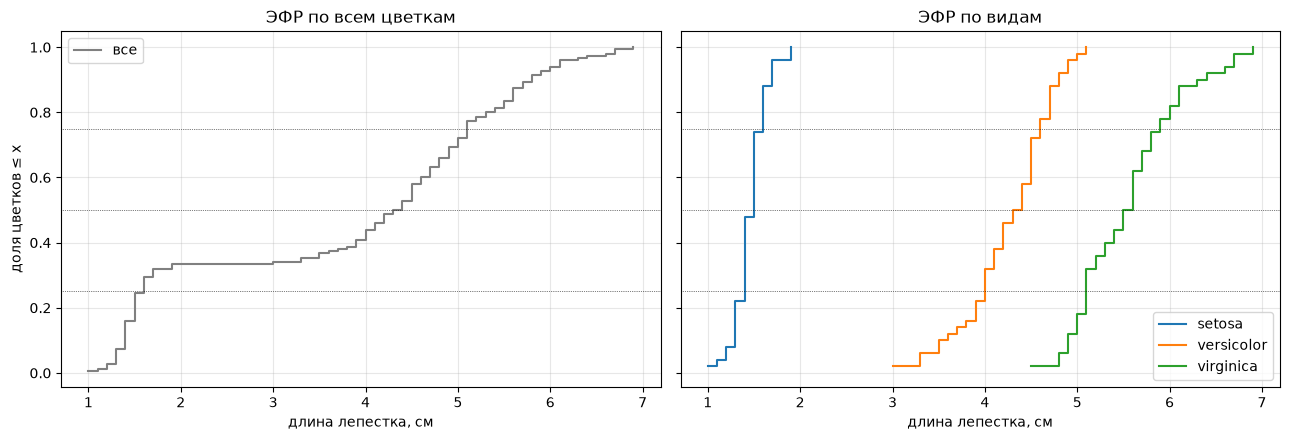

In [4]:
fig = plot_ecdfs(groups)
save_figure(fig, "task_3_ecdfs.png")
plt.show()


**Что видно.** На левом графике ЭФР всех цветков сначала резко поднимается до 1/3 (это все `setosa`), потом идёт длинный горизонтальный участок от 1,9 до 3 см (та самая дыра, цветков там нет), потом снова растёт. На правом графике видно, что ступеньки трёх видов идут друг за другом слева направо: `setosa`, `versicolor`, `virginica`. Кривые `versicolor` и `virginica` частично заходят друг на друга, то есть по длине лепестка эти два вида иногда путаются, а `setosa` не путается ни с кем.

## 3. Гистограммы

Гистограмма делит ось на отрезки (столбики) и показывает, сколько цветков попало в каждый. У всех четырёх гистограмм одинаковые границы столбиков и одинаковая ось $x$, иначе сравнивать их было бы нечестно.

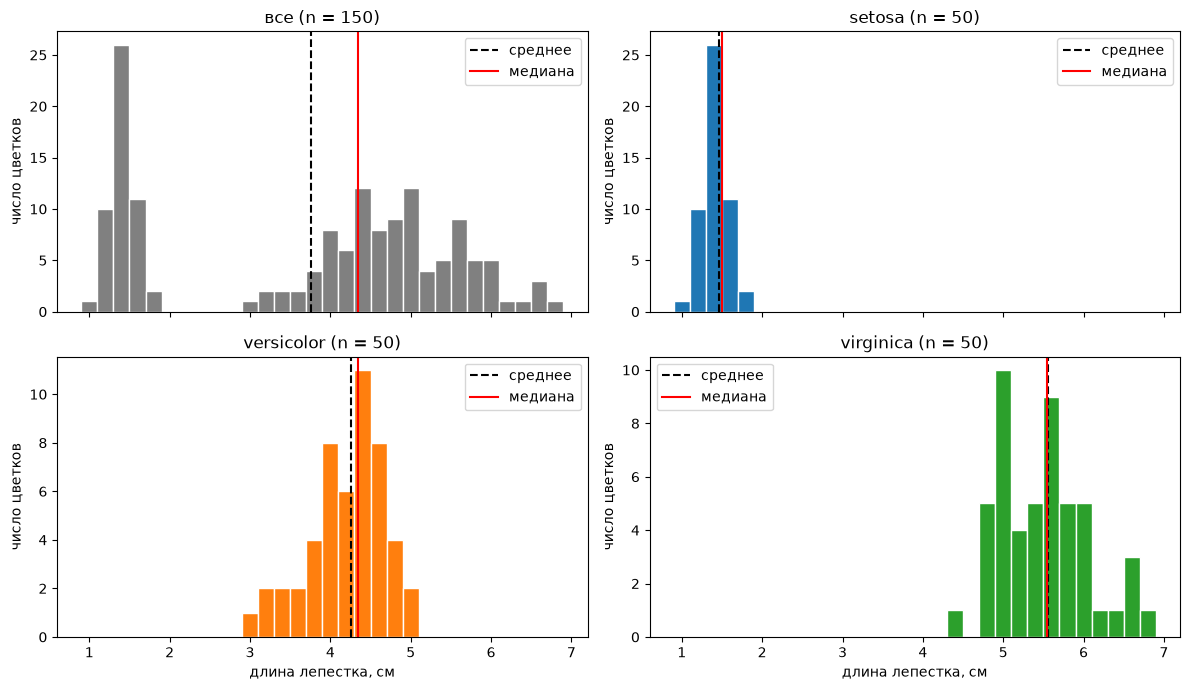

In [5]:
bins = np.arange(0.9, 7.1, 0.2)  # общие границы столбиков, шаг 2 мм
fig = plot_histograms(groups, bins)
save_figure(fig, "task_3_histograms.png")
plt.show()


**Что видно.** Гистограмма всех цветков состоит из двух «горбов» с пустотой между ними: слева узкий высокий горб `setosa`, справа широкий горб из `versicolor` и `virginica` вместе. Пунктир среднего как раз попадает в провал между ними. У каждого вида по отдельности гистограмма одна, примерно симметричная, и среднее с медианой почти совпадают.

## 4. Box plot и violin plot

**Box plot («ящик с усами»):**
- линия внутри ящика это медиана;
- сам ящик идёт от $Q_1$ до $Q_3$, то есть в нём средняя половина данных, а его высота равна IQR;
- усы тянутся до самого дальнего значения, которое ещё не дальше $1{,}5\cdot IQR$ от ящика;
- точки за усами это значения, которые сильно выбиваются из остальных (потенциальные выбросы).

**Violin plot («скрипка»)** показывает примерно то же, но вместо ящика рисует сглаженную форму распределения: где скрипка толще, там больше цветков. По сути это гистограмма, повёрнутая вертикально и отражённая зеркально.

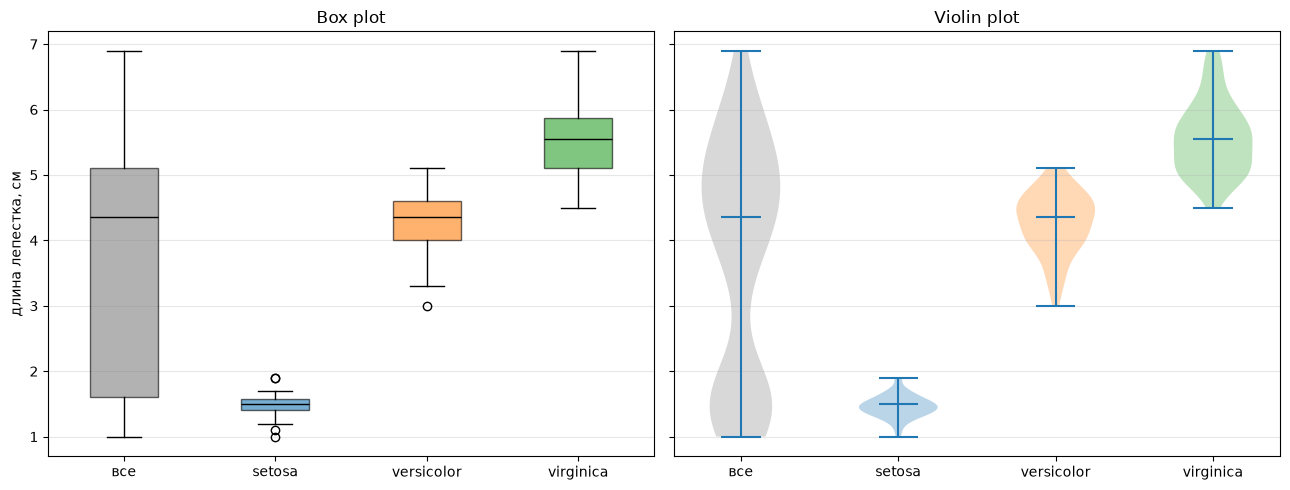

In [6]:
fig = plot_boxplots_and_violins(groups)
save_figure(fig, "task_3_boxplots_violins.png")
plt.show()


**Что видно.**

- На box plot ящик «все» огромный (IQR = 3,5 см), потому что внутри него сидят разные виды. Ящики отдельных видов узкие.
- Ящики `setosa` и остальных видов далеко друг от друга и не пересекаются. Ящики `versicolor` и `virginica` близко, а их усы заходят друг на друга.
- Точки за усами у `setosa` и `versicolor` это просто цветки, которые немного короче или длиннее обычного для своего вида. Ошибками данных они не выглядят: по сравнению с разницей между видами отклонение совсем маленькое.
- На violin plot для «всех» хорошо видна «талия» посередине. Это та же пустота между 1,9 и 3 см, которую box plot вообще не показывает. Вот зачем нужна скрипка: по ящику не скажешь, что у распределения два горба.

## Вывод

- По длине лепестка `setosa` чётко отделяется от остальных: у неё лепестки около 1,5 см, у других видов от 3 см и больше. Между 1,9 и 3,0 см цветков нет вообще.
- `versicolor` (≈ 4,3 см) и `virginica` (≈ 5,5 см) тоже различаются, но частично перекрываются, так что по одной длине лепестка их не всегда можно отличить.
- Статистики по всему датасету (среднее 3,76 см, стандартное отклонение 1,76 см) плохо описывают данные: смешаны разные виды, и «средний» цветок попадает туда, где реальных цветков нет. Поэтому сравнивать надо по классам.
- Анализ чисто описательный: мы смотрим на картинки и числа, но никаких статистических тестов о значимости различий не делаем.